# Multimodal Music Analysis

**Ομάδα:**
- Αθανάσιος Νικολέτας [sdi2300140]
- Αχιλλέας Πετρουλάκης [sdi2300171]


## Installing dependances

In [1]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install scikit-learn
%pip install nltk
%pip install gensim
%pip install wordcloud
%pip install vaderSentiment



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note

## Loading the files and extracting data

In [1]:
import pandas as pd
import os

os.makedirs('../data/processed', exist_ok=True)

id_genres = pd.read_csv('../data/raw/id_genres.csv',sep='\t')
id_information = pd.read_csv('../data/raw/id_information.csv',sep='\t')
id_tags = pd.read_csv('../data/raw/id_tags.csv',sep='\t')


In [2]:
id_mfcc_stats = pd.read_csv('../data/raw/id_mfcc_stats.tsv.bz2',sep='\t',compression='bz2')

## Extract processed_lyrics from a tar.gz and creating processed_lyrics dictionary

For each file:

- get song_id from the filename
- read lyrics
- store to dictionary

make a dataframe using the dictionary

In [6]:
import tarfile
from pathlib import Path

processed_lyrics_dict = {}
with tarfile.open('../data/raw/processed_lyrics.tar.gz', 'r:gz') as tar:
    for member in tar.getmembers():
        if member.isfile():
            file = tar.extractfile(member)
            song_id = Path(member.name).stem
            processed_lyrics_dict[song_id] = file.read().decode('utf-8')

processed_lyrics = pd.DataFrame(
    list(processed_lyrics_dict.items()),
    columns=['id', 'lyrics']
)

processed_lyrics

,id,lyrics
0,9jbSytob9XRzwvB6,deep feel heart burn deep insid yearn know com...
1,Njp6JPM8vitbhVJU,noth hurt like pain someon love noth gain prep...
2,h48f46ZsT9h0Z5Dm,arm side heart sleev chandeli fall stand under...
3,kVtduoU5M56Amw1M,ladi ladi ladi ladi power ladi ladi ladi ladi ...
4,ZmXVK43zlqdeq6z8,end see face recogn thing must left behind pro...
...,...,...
109264,YgII1tHAaAnh14Kf,
109265,5fU9VEvtc2T1J11g,whole town line outsid tent kid think see real...
109266,76qenAf8gYlH4pfq,see store one day think may make play futur mu...
109267,9F8jQjeibAuZinEP,close right sand stretch like child night trus...


## Filtering 

Each song belongs to multiple genres, therefore we explode the genre column so that each song_id, genre becomes a separate row.

Note that id_genres are not clean data and each song can belong to the same genre twice.So we have to remove duplicates.

We then compute the top-5 most frequent genres in the dataset and select songs that belong to at least one of these genres.

Finally, we keep only the songs that exist in all three datasets (genres, lyrics, and stats) by merging them with the id.

In [7]:
# Helper functions

"""
function that explodes a comma-separated (to_explode) column
into multiple rows (new_name column) and returns the new dataframe
with the new column. 
"""
def explode_df(df, to_explode, new_name):
    df = df.copy()
    return df.assign(**{new_name: df[to_explode].str.split(',')}).explode(new_name)


""" 
function that cleans a scpecific column:
    - Replace '-' with space
    - Strip whitespace
    - Remove duplicates
    - returns clean dataframe
"""
def clean_df(df, to_clean):
    df = df.copy()
    df[to_clean] = df[to_clean].apply(
        lambda x: ','.join(dict.fromkeys(
            t.strip() for t in x.replace("-", " ").split(',')
        ))
    )
    return df

"""
function that finds top-N most frequent values
in a comma-separated column and returns value 
count df,top N list values and their frequency.
"""
def find_top_n(df, to_find, n):
    exploded = explode_df(df, to_find, "temp")
    result = exploded["temp"].value_counts().head(n).reset_index()
    result.columns = [to_find, 'count']
    topn_list = result[to_find].tolist()
    list_counts = result['count'].tolist()
    return result, topn_list, list_counts

"""
function that finds if there is at least
a value in a comma-separated column 
that matches with values and returns
filtered data frame.
"""
def find_in_list(df, to_find, values):
    values = set(values)
    mask = df[to_find].apply(
        lambda x: any(val.strip() in values for val in x.split(','))
    )
    return df[mask]

""" 
function that selects the first matching
value with values from a comma-separated
column and returns the df with the new column(new_name).    
"""
def find_primary(df, to_find, values, new_name):
    def first_match(column_val):
        for val in column_val.split(','):
            if val.strip() in values:
                return val.strip()
        return None
    df = df.copy()
    df[new_name] = df[to_find].apply(first_match)
    return df

"""
function that prints information about
the final dataset.
"""
def print_info(top5_data_frame,final):
    print("~Top 5 genres with song count~")
    print(top5_data_frame)
    print("\nshape:", final.shape)
    print("\nfinal_dataframe with columns με στήλες: id, genre, lyrics, mfcc_stats")
    print(final.head())
    print("\ninfo")
    final.info()

"""
function that converts dataframe into 
dictionary mapping.
"""
def df_to_dict(df,keys,values):
    return df.set_index(keys)[values].to_dict()

    

In [8]:
# cleaning dataframe
id_tags    = clean_df(df=id_tags,to_clean="tags")
id_genres  = clean_df(df=id_genres,to_clean="genres")

# find top-5 genres based on their frequency and how many songs each genre has
top5_data_frame,top5_list,top5_counts = find_top_n(df=id_genres,
                                                   to_find="genres",
                                                   n=5)
# find ids that belong to top-5 genres
chosen_id_genres = find_in_list(df=id_genres, 
                                to_find='genres', 
                                values=top5_list).drop_duplicates(subset='id')

# merge lyrics and stats with chosen_ids that belong to top-5 genres and take a sample  
final = chosen_id_genres.merge(processed_lyrics, on='id', how='inner').merge(id_mfcc_stats, on='id', how='inner')
final = final.sample(n=7500, random_state=42).reset_index(drop=True)
final.to_csv('../data/processed/final_dataset.csv', index=False)

print_info(top5_data_frame=top5_data_frame,final=final)


~Top 5 genres with song count~
             genres  count
0              rock  23949
1               pop  20267
2        electronic  11739
3  alternative rock   7591
4        indie rock   7353

shape: (7500, 107)

final_dataframe with columns με στήλες: id, genre, lyrics, mfcc_stats
                 id                                   genres  \
0  rCBwys9UDbrFaqnx  rock,singer songwriter,classic rock,pop   
1  jwJo2kvKA2Gu3ftS       classic rock,rock,progressive rock   
2  bMnqQtrkYjnsrxnp              post hardcore,pop,metalcore   
3  ToVL2QCrrhcqq6Uc                               indie rock   
4  0U91aHvEcuFKaBD1                      folk,indie rock,emo   

                                              lyrics    MFCC000    MFCC001  \
0  well tell everyon disgrac drag name place care...  22.468723  10.656616   
1  close eye moment moment go dream pass eye curi...  22.296486   3.688473   
2  mad give want never feel feel call love call n...  20.657087  -4.007842   
3  hey babi look wa

## Text Embeddings

We preprocess the lyrics by cleaning the text, including lowercasing, removal of non-alphabetic characters, stopword removal, and lemmatization.

Then we train a Word2Vec model using the tokenized lyrics, in order to learn vector representations for each word based on its context.

Finally we compute the average of all word vectors in the song to get a vector for the whole song

In [ ]:
import re
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english')) 
lemmatizer = WordNetLemmatizer()

""" 
function that returns list of cleaned
and lemmatized tokens
"""
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) # we use only letters and spaces

    tokens = word_tokenize(text) # text to words

    tokens = [word for word in tokens if word not in stop_words] # stop_words removal
    tokens = [lemmatizer.lemmatize(word) for word in tokens] # lemmatization

    return tokens


final = final.copy()
final['tokens'] = final['lyrics'].apply(clean_text)

from gensim.models import Word2Vec

# vector for every word
w2v_model = Word2Vec(
    sentences=final['tokens'].tolist(),
    vector_size=200, # desired no. of features/independent variables
    window=5, # context window size
    min_count=2,
    sg = 1, # 1 for skip-gram model
    hs = 0,
    negative = 10, # for negative sampling
    workers= 2, # no.of cores
    seed = 34
)

"""
function that makes one vector using mean
for the whole song from all word vectors
and returns it
"""
def get_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv] 

    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

# convert each song into a vector using mean
text_embeddings = np.array([
    get_embedding(song, w2v_model)
    for song in final['tokens']
])

print(text_embeddings.shape)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


(7500, 200)


## Audio Ebbendings

The audio features consist of high-dimensional MFCC statistics, which result in large and noisy vectors.

To make them easier to use, we first standardize the features and then apply PCA.

This reduces the dimensionality of the data while preserving 95% of the total variance resulting in more meaningful audio embeddings.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

mfcc_cols = [c for c in final.columns if c.startswith('MFCC') or c.startswith('cov_')] # take mfcc and cov_ columns
audio_features = final[mfcc_cols].values # making the matrix

# put all features on the same scale
scaler = StandardScaler()
audio_scaled = scaler.fit_transform(audio_features)

# keep 95% of the information
pca = PCA(n_components=0.95)
audio_embeddings = pca.fit_transform(audio_scaled)

print("Dimensions before changing: ",audio_features.shape[1])
print("After PCA (95% variance): ",audio_embeddings.shape[1])

Dimensions before changing:  104
After PCA (95% variance):  79


## Word Clouds

We extract the tags (which are separated by commas) for the songs belonging to the selected genres, in our example rock and electronic which are completely different.We also count their frequency of each tag to make Word Clouds for each genre.

From Word Clouds, we can observe that these genres are significantly different in terms of thematic content,because in rock there are more traditional, powerful and intese themes and is often linked to earlier decades such as the 60s to 90s. thus in electronic there are more positive,energetic and trend themes which are more common from the 90s to the 2010s.

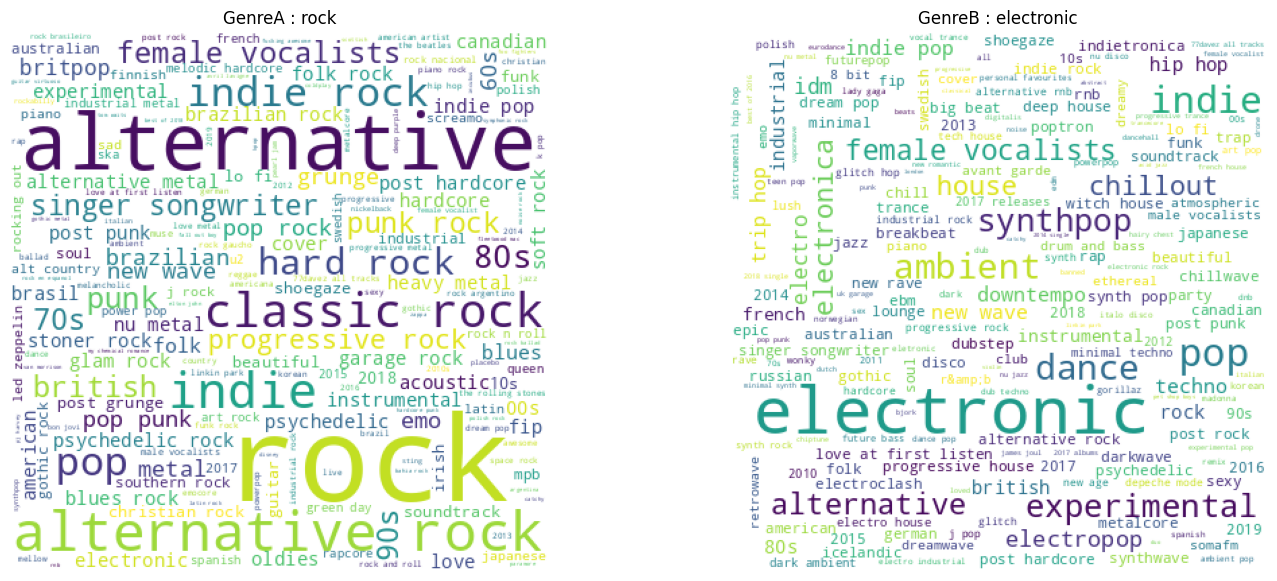

In [28]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# select rock and electronic from our top-5 list
genre_a, genre_b = top5_list[0], top5_list[2]

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

for a, genre,i in zip(axes, [genre_a, genre_b],['A','B']):
    found_genre_ids = find_in_list(df=final,
                                   to_find="genres",
                                   values=[genre])['id'].unique()

    found_id_tags = find_in_list(df=id_tags,
                                 to_find="id",
                                 values=found_genre_ids.tolist())

    # rank all tags
    topn_data_frame, topn_list, topn_counts = find_top_n(df=found_id_tags,
                                                         to_find="tags",
                                                         n=found_id_tags.shape[0])
    # make dictionary for wc
    tag_freq= df_to_dict(df=topn_data_frame,
                         keys="tags",
                         values="count")

    wc = WordCloud(width=400, 
                   height=400, 
                   background_color='white').generate_from_frequencies(tag_freq)
    a.imshow(wc)
    a.set_title(f'Genre{i} : {genre}')
    a.axis('off')

plt.show()

## Bar Chart

We find the most frequent tags for each of the top genres by first splitting the genre column and assigning each song to its corresponding genres.For each genre, we collect all song ids and extract their tags.Then we compute the frequency of each tag by splitting them.Finally, we visualize the top 10 most frequent tags per genre using horizontal bar charts.From the charts we can observe the characteristics of each genre and their relatiionships.Μore specifically all genres except electronic are associated with rock,since rock is the oldest genre.Electronic and pop are also correlated to each other.Rock,indie rock and alternative have more intense and traditional themes thus pop and electronic more modern,energetic and positive themes.

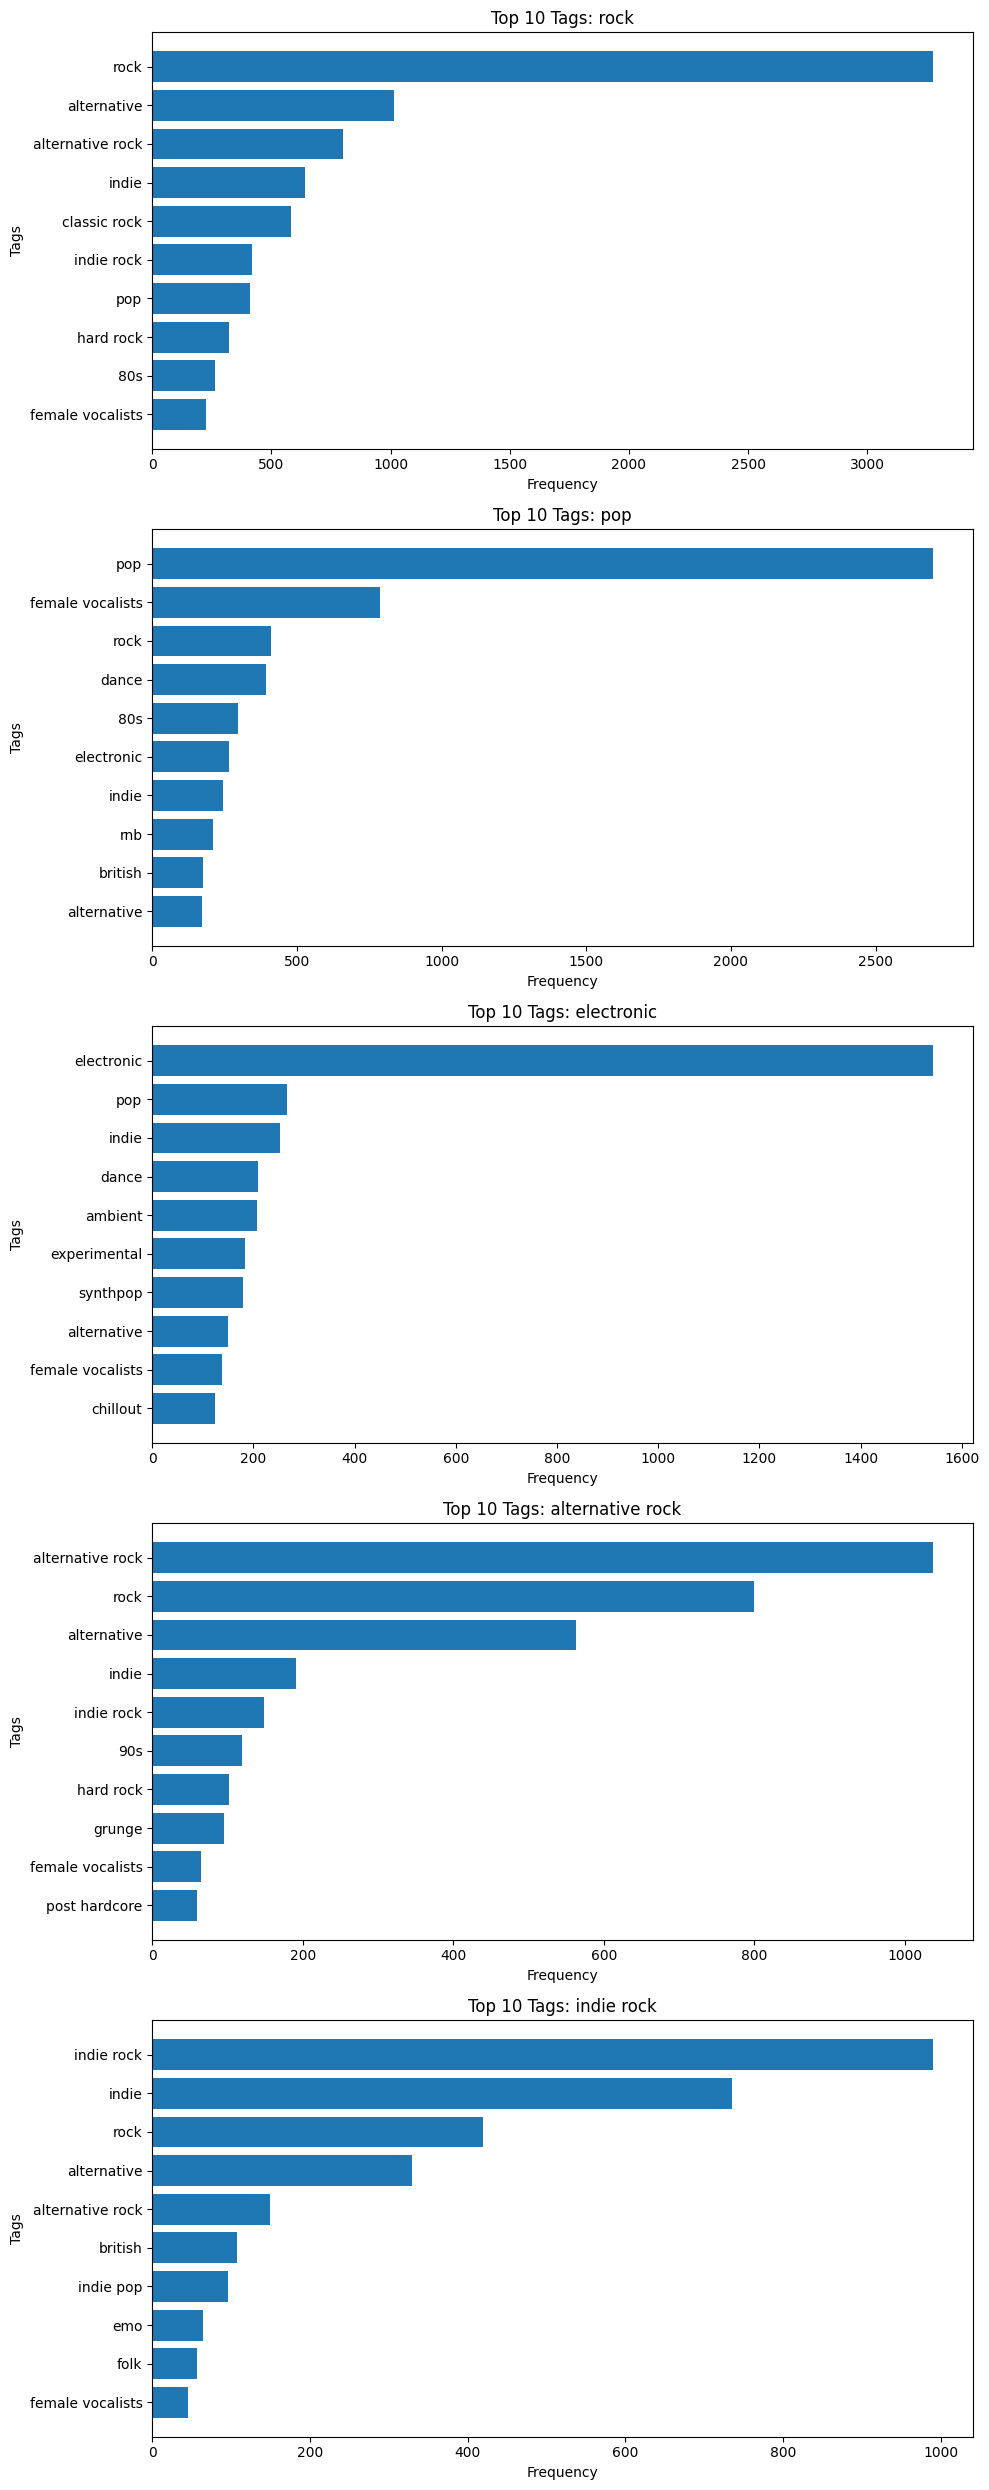

In [16]:
fig, axes = plt.subplots(len(top5_list), 1, figsize=(10, 5 * len(top5_list)))

for axis, genre in zip(axes, top5_list):
    found_genre_ids = find_in_list(df=final,
                               to_find="genres",
                               values=[genre])['id'].unique()

    found_id_tags = find_in_list(df=id_tags,
                             to_find="id",
                             values=found_genre_ids.tolist())


    topn_data_frame, topn_list, topn_counts = find_top_n(df=found_id_tags,
                                                        to_find="tags",
                                                        n=10)

    axis.barh(topn_list, topn_counts)
    axis.invert_yaxis()
    axis.set_title(f'Top 10 Tags: {genre}')
    axis.set_xlabel("Frequency")
    axis.set_ylabel("Tags")


plt.tight_layout()
plt.show()


## 2D Projections of Embeddings
We apply PCA and t-SNE to both text and audio embeddings to project them into 2D.Each song is colored by its primary genre, the first genre that belongs to the top-5.From the plots, we observe that t-SNE produces clearer clusters compared to PCA, as it captures non-linear relationships in the data.Additionally, audio embeddings exhibit more distinct and separable clusters than text embeddings,since mfcc features directly capture acoustic properties that are strongly related to musical genre.On the other hand lyrics can be shared from song to song regardless of the gerne they belong.However in both plots clusters overlap,since rock has heavy impact to the rest of the genres so they can have similar lyrical and acoustic content.

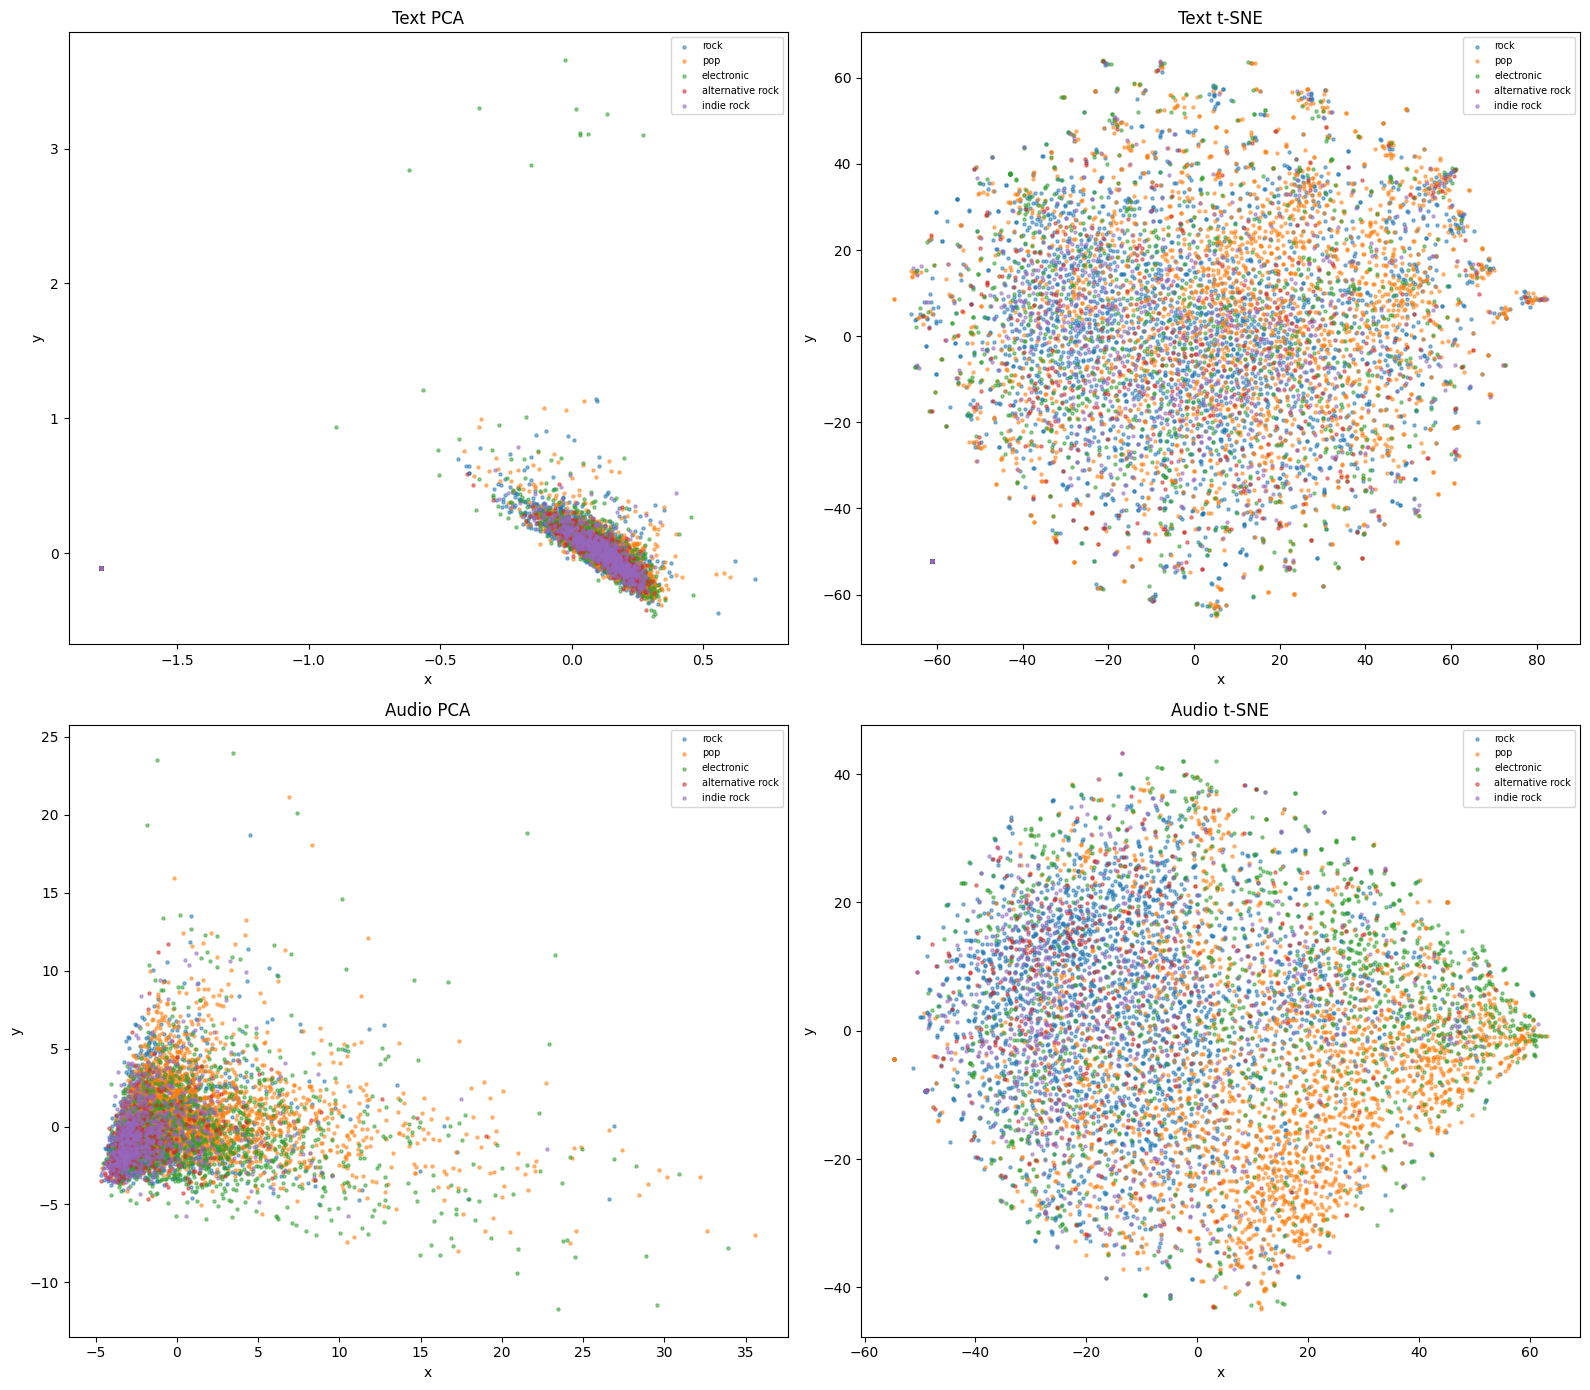

In [19]:
from sklearn.manifold import TSNE


final_primary = find_primary(df=final, to_find="genres", values=top5_list,new_name="primary genre")# chose for every song one primary genre


fig, axes = plt.subplots(2, 2, figsize=(16, 14))


# text
text_2d_pca = PCA(n_components=2).fit_transform(text_embeddings)
text_2d_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(text_embeddings)

# audio
audio_2d_pca = PCA(n_components=2).fit_transform(audio_embeddings)
audio_2d_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(audio_embeddings)

titles = ['Text PCA', 'Text t-SNE', 'Audio PCA', 'Audio t-SNE']
data = [text_2d_pca, text_2d_tsne, audio_2d_pca, audio_2d_tsne]

for ax, title, d in zip(axes.flat, titles, data):
    for genre in top5_list:
        mask = final_primary['primary genre'].values == genre
        ax.scatter(d[mask, 0], d[mask, 1], label=genre, alpha=0.5, s=5)
        
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


## Genre Count Distribution
The distribution of genre counts shows that most songs belong to 2 genres, followed by 3 genres, while single-genre songs are also common. Songs with 4 or more genres are relatively rare.This means that the dataset multiple genres per song, but most songs are associated with a small number of closely related genres.So there is overlap between genres.


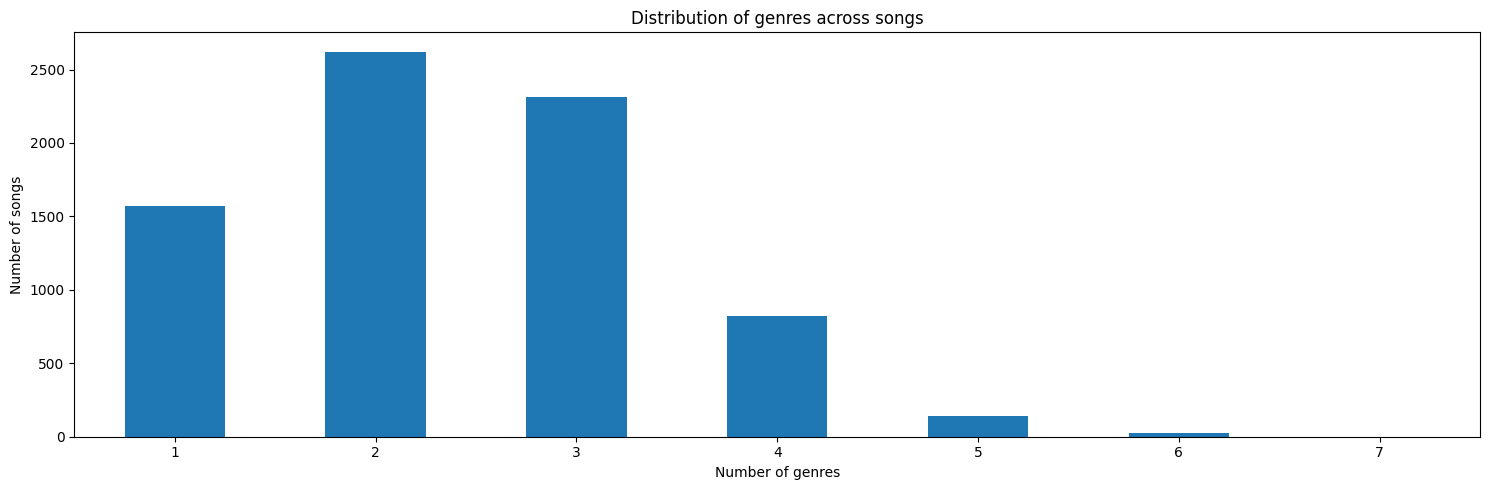

In [39]:
final['genre_count'] = final['genres'].str.split(',').apply(len) # count in how many genres each song belongs

fig, ax = plt.subplots(figsize=(15, 5))
final['genre_count'].value_counts().sort_index().plot(kind='bar', ax=ax) # plot the distribution of genre counts across songs
ax.set_xlabel('Number of genres')
ax.set_ylabel('Number of songs')
ax.set_title('Distribution of genres across songs')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Top 10 Genres

We identify the top 10 most frequent genres in the dataset. Then, we compute how many songs belong to each of these genres.From the plot we observe that rock and pop are the most dominant genres,because they are widely used categories that include many subgenres (alternative rock, indie rock, pop rock). As a result, a large number of songs are assigned to these genres.This leads to higher overall frequency compared to more specific genres.

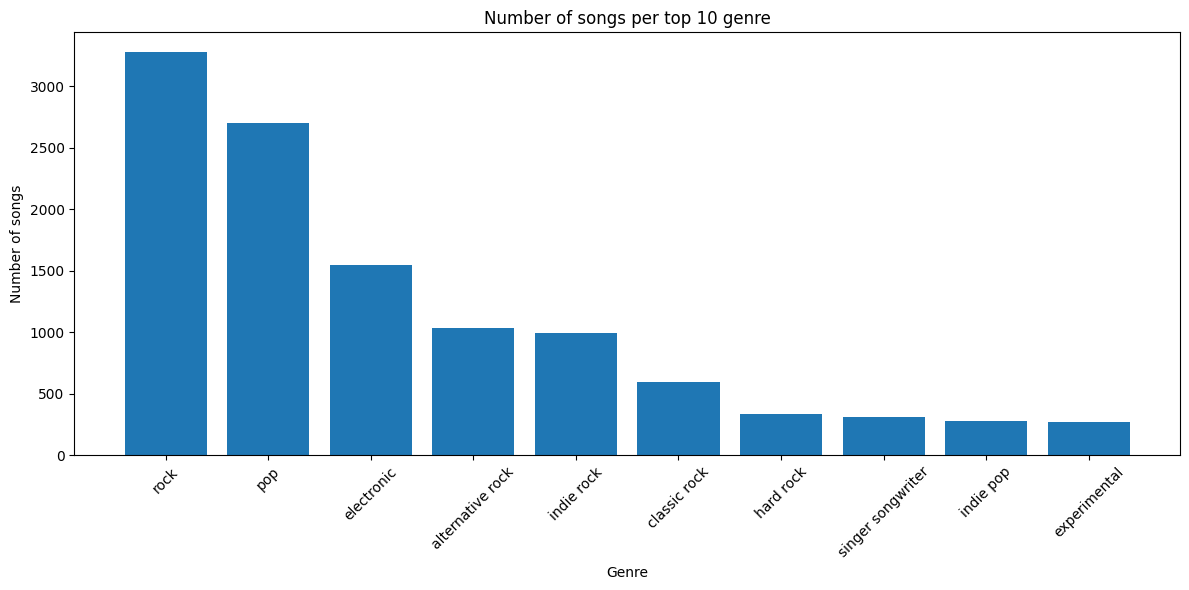

In [49]:
# find the top 10 most frequent genres and their song counts
top10_data_frame, top10_list, top10_counts = find_top_n(df=final,
                                                        to_find="genres",
                                                        n=10)
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(top10_list, top10_counts)
ax.set_title('Number of songs per top 10 genre')
ax.set_xlabel('Genre')
ax.set_ylabel('Number of songs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## The distribution of lyrics length

In terms of word count, most songs contain a moderate number of words, while few have extremely long lyrics.
This is also observed in character count, with most songs clustered in a mid-range but some extending to very large lengths.
This means that the duration of the songs is short to moderate.After removing stopwords, we compute the number of meaningful words per song. The average word count is approximately 108 words per song, while the average number of meaningful words is 107. lyrics already consist mostly of meaningful words, and stopword removal has only a minor impact.

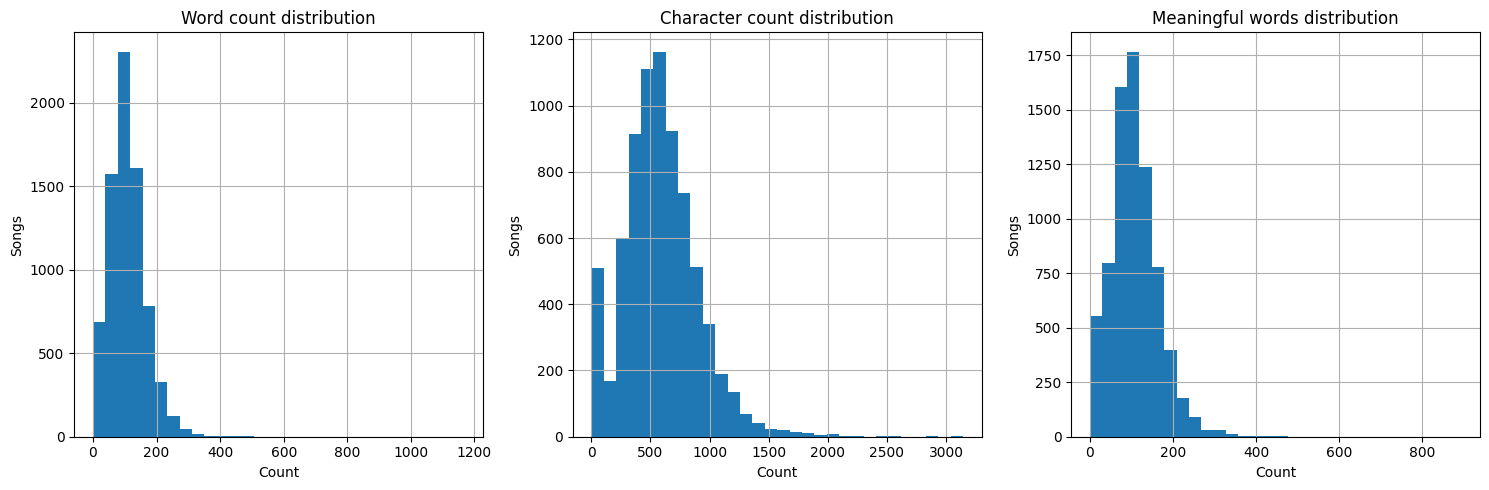

Avg words: 108, Avg meaningful: 107


In [73]:
final['word_count'] = final['lyrics'].str.split().apply(len)
final['char_count'] = final['lyrics'].str.len()
final['meaningful_words'] = final['tokens'].apply(len)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

final['word_count'].hist(bins=30, ax=axes[0])
axes[0].set_title('Word count distribution')

final['char_count'].hist(bins=30, ax=axes[1])
axes[1].set_title('Character count distribution')

final['meaningful_words'].hist(bins=30, ax=axes[2])
axes[2].set_title('Meaningful words distribution')

for ax in axes:
    ax.set_ylabel('Songs')
    ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

print(f"Avg words: {final['word_count'].mean():.0f}, "
      f"Avg meaningful: {final['meaningful_words'].mean():.0f}")


## Sentiment Analysis per Genre
Using the pre-trained VADER sentiment analyzer, we compute a compound sentiment score for each song's lyrics (range: -1 = very negative, +1 = very positive).We then group the songs by their primary genre and compare the distributions to test the hypothesis that pop is happier and rock related genres are more negative, with the most negative to be electronic which support our word cloud analysis that
also concluded pop and electronic are completely diffrent genres.


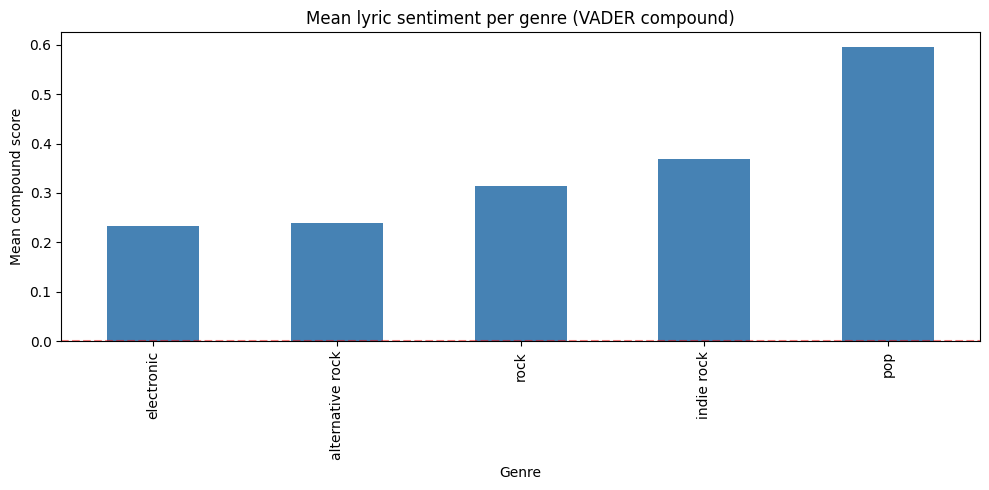

In [110]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
final['sentiment'] = final['lyrics'].apply(lambda t: analyzer.polarity_scores(t)['compound'])

final_primary = find_primary(df=final, to_find="genres", values=top5_list, new_name="primary_genre")

mean_sent = final_primary.groupby('primary_genre')['sentiment'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
mean_sent.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_title('Mean lyric sentiment per genre (VADER compound)')
ax.set_xlabel('Genre')
ax.set_ylabel('Mean compound score')
plt.tight_layout()
plt.show()


## Similarity Analysis

We apply cosine similarity to identify the 5 most similar songs to a given query song, using both lyric embeddings and audio embeddings.

For the lyrics-based embeddings, the most similar songs show very high similarity scores (~0.94). These songs share strong textual and semantic overlap with the query, and they mostly belong to closely related genres such as rock, pop, indie rock, and singer-songwriter. This indicates that the text embeddings successfully capture lyrical content and thematic similarity across songs, even when genres slightly differ.

In contrast, the audio-based similarity results show lower similarity values (~0.55–0.70). While some retrieved songs still belong to related genres (e.g. rock, alternative rock, pop), the overlap is weaker and more diverse. This suggests that audio embeddings capture more general acoustic properties (such as rhythm, energy, and instrumentation) rather than exact genre or lyrical similarity.

Overall, lyrics-based embeddings produce tighter and more semantically consistent clusters, while audio-based embeddings reflect broader musical similarity. This demonstrates that the two modalities capture complementary aspects of music: lyrics focus on meaning and themes, whereas audio focuses on sound and structure.

The similarity results are consistent with the observations from the 2D projections. While the PCA and t-SNE plots show significant overlap between genres at a global level, cosine similarity reveals that locally, songs still tend to group with semantically or acoustically similar neighbors.

In particular, lyrics-based embeddings form very strong local clusters with high similarity scores, indicating that songs share strong thematic and linguistic patterns even if global separation is weak. Audio-based embeddings show lower similarity values and more diverse neighbors, reflecting that acoustic features capture broader and less genre-specific relationships.

Overall, this suggests that the embeddings preserve meaningful local structure even when global cluster separation is not clearly defined.

In [74]:
from sklearn.metrics.pairwise import cosine_similarity

def top5_similar(query_idx, embeddings):
    sims = cosine_similarity([embeddings[query_idx]], embeddings)[0]
    return sims.argsort()[-6:-1][::-1], sims

sample_idx = 0
print(f"Query: {final.iloc[sample_idx]['id']} | genre: {final.iloc[sample_idx]['genres']}\n")

text_top5, text_sim = top5_similar(sample_idx, text_embeddings)
print("Top 5 similar by LYRICS:")
for i in text_top5:
    print(f"  {final.iloc[i]['id']} | {final.iloc[i]['genres']} | sim: {text_sim[i]:.4f}")

audio_top5, audio_sim = top5_similar(sample_idx, audio_embeddings)
print("\nTop 5 similar by AUDIO:")
for i in audio_top5:
    print(f"  {final.iloc[i]['id']} | {final.iloc[i]['genres']} | sim: {audio_sim[i]:.4f}")



Query: rCBwys9UDbrFaqnx | genre: rock,singer songwriter,classic rock,pop

Top 5 similar by LYRICS:
  dSBARVPGZiRvfRZv | indie rock | sim: 0.9442
  Et3rQemSxEl6CNPk | pop | sim: 0.9440
  p5ywwKVV4r0Nz1WA | rock,pop,pop rock | sim: 0.9408
  fJTQmhQSkTOvTJep | pop,singer songwriter | sim: 0.9394
  AokXV8yNzRXOBhx4 | rock,alternative rock | sim: 0.9389

Top 5 similar by AUDIO:
  uUPlXh4lfqK9G8fG | alternative rock,rock,psychobilly | sim: 0.6961
  eVTZuaA1qvBrvyjl | rock,brazilian rock,mpb | sim: 0.6021
  uF9NTRD4vG3Jp8s7 | pop,synthpop | sim: 0.6017
  NydvtdhQbKtdup6M | pop,soft rock,rock | sim: 0.5684
  xVLnf3h6w2nIXWaL | classic rock,rock | sim: 0.5546
